#  Final Model Training & Evaluation

Train the final model using the best hyperparameters obtained during model selection,
and evaluate its performance on a held-out test set.

This evaluation represents the model's expected performance in real-world scenarios.

In [3]:
#Import Libraries

import pandas as pd
import joblib

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
#Loading Data 

import pandas as pd

train = pd.read_csv('/Users/olgabencomo/Desktop/Proyectos Portafolio/Sentiment Analysis Project/data/processed/train.csv')
val = pd.read_csv('/Users/olgabencomo/Desktop/Proyectos Portafolio/Sentiment Analysis Project/data/processed/val.csv')
test = pd.read_csv('/Users/olgabencomo/Desktop/Proyectos Portafolio/Sentiment Analysis Project/data/processed/test.csv')

In [2]:
# Combining Train and Validation Sets for Final Model Training

X_final = pd.concat([train['text'], val['text']])
y_final = pd.concat([train['label'], val['label']])

In [4]:
final_model = joblib.load('/Users/olgabencomo/Desktop/Proyectos Portafolio/Sentiment Analysis Project/models/best_model.pkl')

In [5]:
final_model.fit(X_final, y_final)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [6]:
# Predictions on Test Set

X_test = test['text']
y_test = test['label']

y_test_pred = final_model.predict(X_test)

In [7]:
print(classification_report(y_test, y_test_pred))

print("Accuracy:", accuracy_score(y_test, y_test_pred))

              precision    recall  f1-score   support

    Negative       0.53      0.57      0.55       355
     Neutral       0.39      0.33      0.36       424
    Positive       0.91      0.93      0.92      2618

    accuracy                           0.82      3397
   macro avg       0.61      0.61      0.61      3397
weighted avg       0.81      0.82      0.81      3397

Accuracy: 0.816897262290256


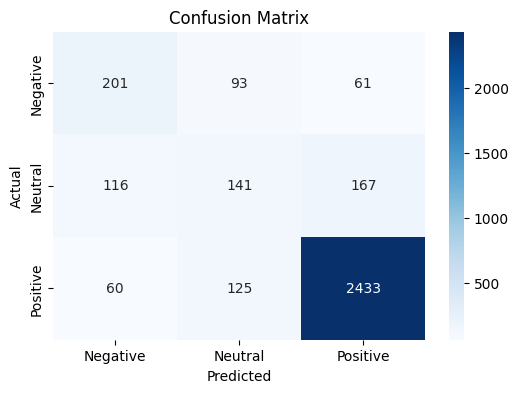

In [8]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [9]:
# Error Analysis

errors = pd.DataFrame({
    'text': X_test,
    'actual': y_test,
    'predicted': y_test_pred
})

errors = errors[errors['actual'] != errors['predicted']]

errors.head(10)

,text,actual,predicted
9,tried store huge couldnt try smaller size trie...,Negative,Positive
16,dress arrived two large buttons missing front ...,Neutral,Negative
20,dress darling well made however runs large tri...,Positive,Neutral
25,lovely skirt fits well much yellowy cream colo...,Neutral,Positive
30,lovely top big billowy makes wish taller think...,Positive,Neutral
38,high hopes top love plaid design found boxy sh...,Positive,Neutral
43,ordered ivory size xl fit little small side kn...,Positive,Neutral
47,im size day everyday pants wouldnt even meet a...,Positive,Negative
49,usually size ordered xs due band center much g...,Negative,Neutral
57,wish would read reviews ordering cute casual t...,Neutral,Positive


## Final Model Evaluation

The final model achieved strong overall performance, with an accuracy of 0.82 and a macro F1-score of 0.61.

### Key Results:
- Excellent performance on the Positive class (F1: 0.92)
- Good performance on the Negative class (F1: 0.55)
- Lower performance on the Neutral class (F1: 0.36)

### Insights:
- The model generalizes well to unseen data, with consistent performance between validation and test sets
- Class imbalance was successfully addressed using class weighting
- The Neutral class remains challenging due to semantic ambiguity

### Key Limitation:
The use of rating-based labels introduces noise, as the sentiment expressed in text does not always align with the numerical rating.

### Final Takeaway:
The model provides a strong baseline for sentiment classification and is suitable for deployment, with future improvements possible through better labeling strategies and advanced NLP models.